Marr Hilderth 

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

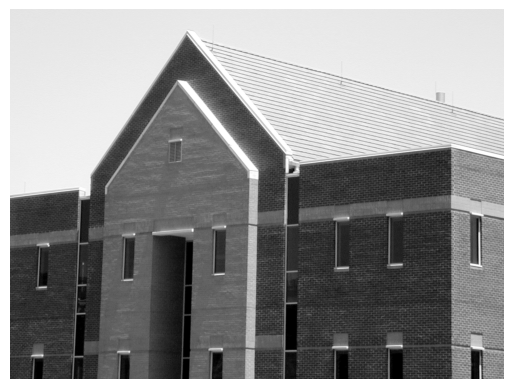

In [ ]:
img=(cv2.imread(r'E:\BG\Building.tif',0))
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.show()

In [2]:
def gaussian_kernel(size,sigma):
    kernel=np.zeros((size,size),dtype=np.float32)
    center=size//2
    for i in range(size):
        for j in range(size):
            x,y=i-center,j-center
            kernel[i,j]=np.exp(-(x**2+y**2)/(2*sigma**2))
    return kernel

In [3]:
def laplacian(img):
    kernel=np.array([[0,1,0],[1,-4,1],[0,1,0]])
    rows,cols=img.shape
    output=np.zeros((rows,cols))
    for i in range(rows-2):
        for j in range(cols-2):
            reg=img[i:i+3,j:j+3]
            output[i,j]=np.sum(reg*kernel)
    return output

In [4]:
def general_convolution(img,kernel):
    img_h,img_w=img.shape
    kernel_h,kernel_w=kernel.shape
    pad_h=kernel_h//2
    pad_w=kernel_w//2
    
    padded_img=np.pad(img,((pad_h,pad_h),(pad_w,pad_w)),mode='constant',constant_values=0)
    
    output_img=np.zeros((img_h,img_w))
    
    for i in range(img_h):
        for j in range(img_w):
            reg=padded_img[i:i+kernel_h,j:j+kernel_w]
            output_img[i,j]=np.sum(reg*kernel)
            
    return output_img

In [12]:
def zero_crossing(img):
    output=np.zeros_like(img)
    rows,cols=img.shape
    for i in range(1,rows-1):
        for j in range(1,cols-1):
                if (img[i-1,j]<0 and img[i+1,j]>0) or (img[i-1,j]>0 and img[i+1,j]<0) or (img[i,j-1]<0 and img[i,j+1]>0) or (img[i,j-1]>0 and img[i,j+1]<0):
                    output[i,j]=255
    return output

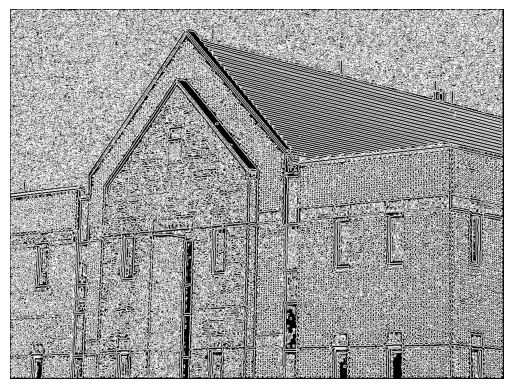

In [15]:
def marr_hilder(img,sigma):
    kernel=gaussian_kernel(5,sigma)
    blurred=general_convolution(img,kernel)
    laplacian_img=laplacian(blurred)
    edges=zero_crossing(laplacian_img)
    return edges
out_img=marr_hilder(img,3.0)
plt.imshow(out_img,cmap='gray')
plt.axis('off')
plt.show()
